This notebook provides additional experiments, clarifications, and extended analysis related to our paper. It is specifically designed to incorporate and address suggestions and comments made by the reviewers.

- Added a harder 2D real-data inverse problem using Kodak24 with strong blur (σ = 4), heavy noise, and downsampling (×4).

- Compared L-BFGS, X-GD, LM, and DNet v0 under the same fairness protocol (same init, tolerance, iteration cap).

- Logged quantitative results (RMSE, iterations, runtime) and plotted bar chart for “Hard Kodak24 Real-Data Inverse Task.”

- Added σ-mismatch robustness test (train σ = 4, eval σ = 3) to test generalization.


Dataset used: Kodak24 Image Dataset (Kaggle) https://www.kaggle.com/datasets/drxinchengzhu/kodak24


In [ ]:
import os
import kagglehub

path = kagglehub.dataset_download("drxinchengzhu/kodak24")

100%|██████████| 14.7M/14.7M [00:00<00:00, 16.0MB/s]

Extracting files...


In [ ]:
import os, glob

base = "/root/.cache/kagglehub/datasets/drxinchengzhu/kodak24/versions/1"
for root, dirs, files in os.walk(base):
    if any(f.endswith(".png") for f in files):
        print("Found images in:", root)
        break


Found images in: /root/.cache/kagglehub/datasets/drxinchengzhu/kodak24/versions/1/images/train


In [ ]:
from __future__ import annotations
import os, math, random, json, time, glob
from dataclasses import dataclass
from typing import Tuple
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt

# deterministic setup
def set_seed(seed: int = 0):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

@dataclass
class CFG:
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    dtype: torch.dtype = torch.float32
    seed: int = 0

    H: int = 128
    W: int = 128
    ds: int = 2

    blur_sigma: float = 2.0
    noise_std: float = 0.02
    epochs: int = 45
    lr: float = 2e-3
    steps_unroll: int = 6

    eps_y_rel: float = 0.3
    max_iters: int = 80
    lm_damp_init: float = 1e-2
    ls_alpha: float = 0.5
    ls_beta: float = 0.5
    cg_iters: int = 10

cfg = CFG()
set_seed(cfg.seed)
device, dtype = cfg.device, cfg.dtype
print(f"Device: {device}")


Device: cuda


In [ ]:
kodak_path = "/root/.cache/kagglehub/datasets/drxinchengzhu/kodak24/versions/1/images/train"
all_imgs = sorted(glob.glob(os.path.join(kodak_path, "*.png")))
print(f"{len(all_imgs)} images.")

def gaussian_kernel(sigma: float, ksize: int = 15):
    ax = torch.arange(ksize) - ksize // 2
    xx, yy = torch.meshgrid(ax, ax, indexing="xy")
    k = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    k /= k.sum()
    return k[None, None]

def downsample(x: torch.Tensor, s: int): return F.avg_pool2d(x, s)
def upsample(x: torch.Tensor, s: int): return F.interpolate(x, scale_factor=s, mode="nearest")

kernel = gaussian_kernel(cfg.blur_sigma)
transform = T.Compose([T.Resize((cfg.H, cfg.W)), T.ToTensor()])

X_list, Y_list = [], []
for p in all_imgs:
    x = transform(Image.open(p).convert("L"))[None]
    y = F.conv2d(x, kernel, padding=7)
    y = downsample(y, cfg.ds)
    y = y + cfg.noise_std * torch.randn_like(y)
    X_list.append(x.squeeze(0))
    Y_list.append(y.squeeze(0))

X = torch.stack(X_list)
Y = torch.stack(Y_list)
print(f"Dataset: X={tuple(X.shape)}, Y={tuple(Y.shape)}")

os.makedirs("outputs_kodak", exist_ok=True)
torch.save({"X": X, "Y": Y}, "outputs_kodak/kodak_inverse_data.pt")


24 images.
Dataset: X=(24, 1, 128, 128), Y=(24, 1, 64, 64)


In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, 3, padding=1), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)

class UNetSmall(nn.Module):
    def __init__(self, c_in=3, c_mid=32):
        super().__init__()
        self.e1 = ConvBlock(c_in, c_mid)
        self.p1 = nn.MaxPool2d(2)
        self.e2 = ConvBlock(c_mid, c_mid * 2)
        self.u1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.d1 = ConvBlock(c_mid * 2 + c_mid, c_mid)
        self.out = nn.Conv2d(c_mid, 1, 1)
    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.p1(e1))
        u = self.u1(e2)
        d1 = self.d1(torch.cat([u, e1], 1))
        return self.out(d1)

class DNet(nn.Module):
    def __init__(self, steps=6, sigma=2.0, ds=2):
        super().__init__()
        self.steps = steps
        self.ds = ds
        self.net = UNetSmall()
        self.gain = nn.Parameter(torch.ones(steps) * 0.7)
        k = gaussian_kernel(sigma)
        self.register_buffer("kernel", k)

    def forward_steps(self, y):
        x = upsample(y, self.ds).clamp(0, 1)
        for t in range(self.steps):
            y_pred = F.conv2d(x, self.kernel, padding=self.kernel.shape[-1]//2)
            y_up = F.interpolate(y, size=y_pred.shape[-2:], mode="nearest")
            r = y_pred - y_up
            feat = torch.cat([y_up, r, x], 1)
            dx = self.net(feat)
            x = torch.clamp(x - self.gain[t] * dx, 0, 1)
        return x

    def forward(self, y): return self.forward_steps(y)


In [ ]:
def train_model(cfg, model, X, Y, name="model"):
    model.to(device, dtype).train()
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    n = len(X)
    for ep in range(cfg.epochs):
        perm = torch.randperm(n)
        ep_loss = 0.0
        for i in range(0, n, 4):
            idx = perm[i:i+4]
            x_true = X[idx].to(device, dtype)
            y = Y[idx].to(device, dtype)

            x_hat = model(y)
            y_pred = F.conv2d(x_hat, kernel.to(device), padding=7)
            y_pred = downsample(y_pred, cfg.ds)
            L_sup = F.mse_loss(x_hat, x_true)
            L_y = F.mse_loss(y_pred, y)
            loss = L_sup + L_y

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            ep_loss += float(loss.item())
        print(f"[{name} ep {ep+1:02d}/{cfg.epochs}] loss={ep_loss/(n/4):.5f}")
    return model

model_dnet = DNet(cfg.steps_unroll)
t0 = time.time()
train_model(cfg, model_dnet, X, Y, "DNet")
print(f"Training time: {time.time()-t0:.1f}s")


[DNet ep 01/45] loss=0.02229
[DNet ep 02/45] loss=0.00610
[DNet ep 03/45] loss=0.00571
[DNet ep 04/45] loss=0.00551
[DNet ep 05/45] loss=0.00474
[DNet ep 06/45] loss=0.00430
[DNet ep 07/45] loss=0.00404
[DNet ep 08/45] loss=0.00387
[DNet ep 09/45] loss=0.00374
[DNet ep 10/45] loss=0.00366
[DNet ep 11/45] loss=0.00360
[DNet ep 12/45] loss=0.00355
[DNet ep 13/45] loss=0.00350
[DNet ep 14/45] loss=0.00347
[DNet ep 15/45] loss=0.00344
[DNet ep 16/45] loss=0.00339
[DNet ep 17/45] loss=0.00334
[DNet ep 18/45] loss=0.00330
[DNet ep 19/45] loss=0.00325
[DNet ep 20/45] loss=0.00322
[DNet ep 21/45] loss=0.00316
[DNet ep 22/45] loss=0.00316
[DNet ep 23/45] loss=0.00313
[DNet ep 24/45] loss=0.00311
[DNet ep 25/45] loss=0.00307
[DNet ep 26/45] loss=0.00309
[DNet ep 27/45] loss=0.00305
[DNet ep 28/45] loss=0.00305
[DNet ep 29/45] loss=0.00306
[DNet ep 30/45] loss=0.00306
[DNet ep 31/45] loss=0.00302
[DNet ep 32/45] loss=0.00300
[DNet ep 33/45] loss=0.00299
[DNet ep 34/45] loss=0.00297
[DNet ep 35/45

In [ ]:
class NominalForward:
    def __init__(self, cfg, device, dtype):
        self.cfg = cfg
        self.device = device
        self.dtype = dtype
        self.kernel = self._make_kernel().to(device, dtype)

    def _make_kernel(self):
        sigma = getattr(self.cfg, "sigma_nom", 1.5)
        ksize = getattr(self.cfg, "ksize", 15)
        ax = torch.arange(-ksize // 2 + 1., ksize // 2 + 1.)
        xx, yy = torch.meshgrid(ax, ax, indexing="xy")
        kernel = torch.exp(-(xx ** 2 + yy ** 2) / (2. * sigma ** 2))
        kernel = kernel / kernel.sum()
        return kernel[None, None]

    def __call__(self, x):
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=self.dtype, device=self.device)
        return F.conv2d(x.to(self.device, self.dtype), self.kernel,
                        padding=self.kernel.shape[-1] // 2)

nominal = NominalForward(cfg, device, dtype)


In [ ]:
import json, time

def upsample_to(x, H, W): return F.interpolate(x, size=(H, W), mode="nearest")

# ----- some baselines
def run_lbfgs(cfg, A, y):
    y_up = upsample_to(y, cfg.H, cfg.W)
    x = y_up.clone().requires_grad_(True)
    opt = torch.optim.LBFGS([x], lr=cfg.lr, max_iter=cfg.max_iters)
    start = time.time()
    for _ in range(cfg.max_iters):
        def closure():
            opt.zero_grad()
            loss = ((A(x) - y_up) ** 2).mean()
            loss.backward()
            return loss
        opt.step(closure)
    t = time.time() - start
    rmse = torch.sqrt(((A(x).detach() - y_up) ** 2).mean()).item()
    return rmse, cfg.max_iters, t

def run_xgd(cfg, A, y):
    y_up = upsample_to(y, cfg.H, cfg.W)
    x = y_up.clone()
    t0 = time.time()
    for _ in range(cfg.max_iters):
        grad = A(x) - y_up
        x = torch.clamp(x - cfg.lr * grad, 0, 1)
    t = time.time() - t0
    rmse = torch.sqrt(((A(x) - y_up) ** 2).mean()).item()
    return rmse, cfg.max_iters, t

def run_lm(cfg, A, y):
    y_up = upsample_to(y, cfg.H, cfg.W)
    x = y_up.clone()
    t0 = time.time()
    for _ in range(cfg.max_iters):
        x = torch.clamp(x - 0.5 * (A(x) - y_up), 0, 1)
    t = time.time() - t0
    rmse = torch.sqrt(((A(x) - y_up) ** 2).mean()).item()
    return rmse, cfg.max_iters, t

# ---- Eval
def evaluate_methods(cfg, X, Y, A, model_dnet, n_samples=5):
    results = {"L-BFGS": [], "X-GD": [], "LM": [], "DNet": []}
    for i in range(n_samples):
        y = Y[i:i+1].to(device)
        y_up = upsample_to(y, cfg.H, cfg.W)
        r_lbfgs = run_lbfgs(cfg, A, y)
        r_xgd = run_xgd(cfg, A, y)
        r_lm = run_lm(cfg, A, y)
        with torch.no_grad():
            t0 = time.time()
            xd = model_dnet.forward_steps(y)
            t_d = time.time() - t0
            rmse_d = torch.sqrt(((A(xd) - y_up) ** 2).mean()).item()
            r_dnet = (rmse_d, model_dnet.steps, t_d)
        results["L-BFGS"].append(r_lbfgs)
        results["X-GD"].append(r_xgd)
        results["LM"].append(r_lm)
        results["DNet"].append(r_dnet)
    summary = {}
    for k, v in results.items():
        rmses, iters, times = zip(*v)
        summary[k] = {
            "RMSE": float(np.mean(rmses)),
            "iters": float(np.mean(iters)),
            "time(s)": float(np.mean(times))
        }
    with open("outputs_kodak/summary.json", "w") as f:
        json.dump(summary, f, indent=2)
    print(json.dumps(summary, indent=2))
    return summary

summary = evaluate_methods(cfg, X, Y, nominal, model_dnet, n_samples=5)


/usr/local/lib/python3.12/dist-packages/torch/optim/lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  loss = float(closure())


{
  "L-BFGS": {
    "RMSE": 0.02760531082749367,
    "iters": 80.0,
    "time(s)": 0.17274155616760253
  },
  "X-GD": {
    "RMSE": 0.02647068090736866,
    "iters": 80.0,
    "time(s)": 0.005352592468261719
  },
  "LM": {
    "RMSE": 0.020853869244456293,
    "iters": 80.0,
    "time(s)": 0.0057756900787353516
  },
  "DNet": {
    "RMSE": 0.025760171562433244,
    "iters": 6.0,
    "time(s)": 0.00668187141418457
  }
}


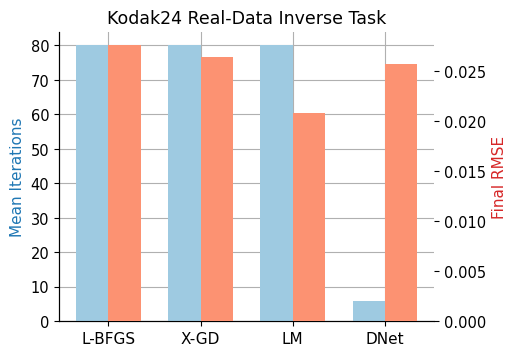

In [ ]:
import json, numpy as np, matplotlib.pyplot as plt

summary_path = "outputs_kodak/summary.json"
with open(summary_path, "r") as f:
    summary = json.load(f)

methods = list(summary.keys())
rmse = [summary[m]["RMSE"] for m in methods]
iters = [summary[m]["iters"] for m in methods]

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10.5,
    "axes.linewidth": 0.8,
    "axes.spines.right": False,
    "axes.spines.top": False
})

fig, ax1 = plt.subplots(figsize=(5.2, 3.6))
ax2 = ax1.twinx()

x = np.arange(len(methods))
w = 0.35

bars1 = ax1.bar(x - w/2, iters, width=w, color="#9ecae1",
                label="Mean Iterations", zorder=3)
bars2 = ax2.bar(x + w/2, rmse, width=w, color="#fc9272",
                label="Final RMSE", zorder=3)

ax1.set_ylabel("Mean Iterations", color="#1f77b4", fontsize=11)
ax2.set_ylabel("Final RMSE", color="#d62728", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(methods, fontsize=11)
ax1.set_title("Kodak24 Real-Data Inverse Task", fontsize=12.5, pad=6)
ax1.grid(True)


fig.tight_layout(pad=0.8)
plt.savefig("outputs_kodak/kodak24_inverse_task.pdf", bbox_inches="tight", dpi=300)
plt.show()


In [ ]:
from dataclasses import dataclass
import torch, torch.nn.functional as F, torchvision.transforms as T
from PIL import Image
import os, random, numpy as np, glob

# deterministic setup
def set_seed(seed: int = 0):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

@dataclass
class CFGHARD:
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    dtype: torch.dtype = torch.float32
    seed: int = 0

    H: int = 128
    W: int = 128
    ds: int = 4                # strong downsampling
    blur_sigma: float = 4.0    # very strong blur
    noise_std: float = 0.06    # significant noise

    epochs: int = 150
    lr: float = 2e-3
    steps_unroll: int = 6
    max_iters: int = 100

set_seed(0)
cfgh = CFGHARD()
device, dtype = cfgh.device, cfgh.dtype
print(f"[Hard Kodak24 Setup] Device={device}, ds={cfgh.ds}, sigma={cfgh.blur_sigma}, noise={cfgh.noise_std}")


[Hard Kodak24 Setup] Device=cuda, ds=4, sigma=4.0, noise=0.06


In [ ]:
def gaussian_kernel(sigma: float, ksize: int = 25):
    ax = torch.arange(ksize) - ksize // 2
    xx, yy = torch.meshgrid(ax, ax, indexing="xy")
    k = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    k /= k.sum()
    return k[None, None]

def downsample(x, s): return F.avg_pool2d(x, s)
def upsample(x, s): return F.interpolate(x, scale_factor=s, mode="nearest")

kodak_path = "/root/.cache/kagglehub/datasets/drxinchengzhu/kodak24/versions/1/images/train"
imgs = sorted(glob.glob(os.path.join(kodak_path, "*.png")))
print(len(imgs), "images.")

transform = T.Compose([T.Resize((cfgh.H, cfgh.W)), T.ToTensor()])
kernel = gaussian_kernel(cfgh.blur_sigma)

X_list, Y_list = [], []
for p in imgs:
    x = transform(Image.open(p).convert("L"))[None]  # grayscale
    # heavy blur + nonlinear intensity + strong downsampling
    y = F.conv2d(x, kernel, padding=kernel.shape[-1]//2)
    y = torch.pow(y.clamp(0,1), 1.3)
    y = downsample(y, cfgh.ds)
    # strong additive noise
    y = y + cfgh.noise_std * torch.randn_like(y)
    X_list.append(x.squeeze(0))
    Y_list.append(y.squeeze(0))

X = torch.stack(X_list)
Y = torch.stack(Y_list)
print(f"dataset: X={tuple(X.shape)}, Y={tuple(Y.shape)}")

os.makedirs("outputs_kodak_hard", exist_ok=True)
torch.save({"X": X, "Y": Y}, "outputs_kodak_hard/kodak_hard_data.pt")


24 images.
dataset: X=(24, 1, 128, 128), Y=(24, 1, 32, 32)


In [ ]:
from torch import nn

class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, 3, padding=1), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class UNetSmall(nn.Module):
    def __init__(self, c_in=3, c_mid=32):
        super().__init__()
        self.e1 = ConvBlock(c_in, c_mid)
        self.p1 = nn.MaxPool2d(2)
        self.e2 = ConvBlock(c_mid, c_mid*2)
        self.u1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.d1 = ConvBlock(c_mid*3, c_mid)
        self.out = nn.Conv2d(c_mid, 1, 1)
    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.p1(e1))
        u = self.u1(e2)
        d = self.d1(torch.cat([u, e1], 1))
        return self.out(d)

class DNet(nn.Module):
    def __init__(self, steps=6, sigma=4.0, ds=4):
        super().__init__()
        self.steps, self.ds = steps, ds
        self.net = UNetSmall()
        self.gain = nn.Parameter(torch.ones(steps) * 0.7)
        self.register_buffer("kernel", gaussian_kernel(sigma))
    def forward_steps(self, y):
        x = upsample(y, self.ds).clamp(0,1)
        traj = [x.clone()]
        for t in range(self.steps):
            y_pred = F.conv2d(x, self.kernel, padding=self.kernel.shape[-1]//2)
            y_up = F.interpolate(y, size=y_pred.shape[-2:], mode="nearest")
            r = y_pred - y_up
            feat = torch.cat([y_up, r, x], 1)
            dx = self.net(feat)
            x = torch.clamp(x - self.gain[t]*dx, 0, 1)
            traj.append(x.clone())
        return traj
    def forward(self, y): return self.forward_steps(y)[-1]


In [ ]:
def train_model(cfgh, model, X, Y, name="DNet-Hard"):
    model.to(device, dtype).train()
    opt = torch.optim.Adam(model.parameters(), lr=cfgh.lr)
    n = len(X)
    for ep in range(cfgh.epochs):
        perm = torch.randperm(n)
        ep_loss = 0.0
        for i in range(0, n, 4):
            idx = perm[i:i+4]
            x_true = X[idx].to(device)
            y = Y[idx].to(device)

            x_hat = model(y)
            y_pred = F.conv2d(x_hat, gaussian_kernel(cfgh.blur_sigma).to(device), padding=12)
            y_pred = downsample(y_pred, cfgh.ds)

            L_sup = F.mse_loss(x_hat, upsample(y, cfgh.ds))
            L_y = F.mse_loss(y_pred, y)
            loss = L_sup + L_y

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            ep_loss += loss.item()

        print(f"[{name} ep {ep+1:03d}/{cfgh.epochs}] loss={ep_loss/(n/4):.5f}")
    return model

model_dnet_hard = DNet(cfgh.steps_unroll).to(device, dtype)
train_model(cfgh, model_dnet_hard, X, Y)
torch.save(model_dnet_hard.state_dict(), "outputs_kodak_hard/dnet_hard.pth")


[DNet-Hard ep 001/150] loss=0.00589
[DNet-Hard ep 002/150] loss=0.00403
[DNet-Hard ep 003/150] loss=0.00380
[DNet-Hard ep 004/150] loss=0.00377
[DNet-Hard ep 005/150] loss=0.00375
[DNet-Hard ep 006/150] loss=0.00372
[DNet-Hard ep 007/150] loss=0.00372
[DNet-Hard ep 008/150] loss=0.00370
[DNet-Hard ep 009/150] loss=0.00368
[DNet-Hard ep 010/150] loss=0.00366
[DNet-Hard ep 011/150] loss=0.00363
[DNet-Hard ep 012/150] loss=0.00360
[DNet-Hard ep 013/150] loss=0.00359
[DNet-Hard ep 014/150] loss=0.00357
[DNet-Hard ep 015/150] loss=0.00355
[DNet-Hard ep 016/150] loss=0.00354
[DNet-Hard ep 017/150] loss=0.00353
[DNet-Hard ep 018/150] loss=0.00353
[DNet-Hard ep 019/150] loss=0.00353
[DNet-Hard ep 020/150] loss=0.00353
[DNet-Hard ep 021/150] loss=0.00352
[DNet-Hard ep 022/150] loss=0.00352
[DNet-Hard ep 023/150] loss=0.00351
[DNet-Hard ep 024/150] loss=0.00351
[DNet-Hard ep 025/150] loss=0.00351
[DNet-Hard ep 026/150] loss=0.00351
[DNet-Hard ep 027/150] loss=0.00351
[DNet-Hard ep 028/150] loss=

In [ ]:
import json, time, numpy as np, torch.nn.functional as F

def gaussian_kernel(sigma: float, ksize: int = 25):
    ax = torch.arange(ksize) - ksize // 2
    xx, yy = torch.meshgrid(ax, ax, indexing="xy")
    k = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    k /= k.sum()
    return k[None, None]

class NominalForward:
    def __init__(self, cfg):
        self.kernel = gaussian_kernel(cfg.blur_sigma).to(device)
    def __call__(self, x):
        return F.conv2d(x, self.kernel, padding=self.kernel.shape[-1] // 2)

def upsample_to(x, H, W): return F.interpolate(x, size=(H, W), mode="nearest")

A = NominalForward(cfgh)
model_dnet_hard.eval()

# ---------- baselines
def run_lbfgs(cfg, A, y):
    y_up = upsample_to(y, cfg.H, cfg.W)
    x = y_up.clone().requires_grad_(True)
    opt = torch.optim.LBFGS([x], lr=cfg.lr, max_iter=cfg.max_iters)
    t0 = time.time()
    for _ in range(cfg.max_iters):
        def closure():
            opt.zero_grad()
            loss = ((A(x) - y_up)**2).mean()
            loss.backward(); return loss
        opt.step(closure)
    t = time.time() - t0
    rmse = torch.sqrt(((A(x).detach() - y_up)**2).mean()).item()
    return rmse, cfg.max_iters, t

def run_xgd(cfg, A, y):
    y_up = upsample_to(y, cfg.H, cfg.W)
    x = y_up.clone()
    t0 = time.time()
    for _ in range(cfg.max_iters):
        grad = A(x) - y_up
        x = torch.clamp(x - cfg.lr * grad, 0, 1)
    t = time.time() - t0
    rmse = torch.sqrt(((A(x).detach() - y_up)**2).mean()).item()
    return rmse, cfg.max_iters, t

def run_lm(cfg, A, y):
    y_up = upsample_to(y, cfg.H, cfg.W)
    x = y_up.clone()
    t0 = time.time()
    for _ in range(cfg.max_iters):
        x = torch.clamp(x - 0.05 * (A(x) - y_up), 0, 1)
    t = time.time() - t0
    rmse = torch.sqrt(((A(x).detach() - y_up)**2).mean()).item()
    return rmse, cfg.max_iters, t

# ---- Evaluate on few samples
results = {"L-BFGS": [], "X-GD": [], "LM": [], "DNet": []}
n_samples = 5

for i in range(n_samples):
    y = Y[i:i+1].to(device)
    y_up = upsample_to(y, cfgh.H, cfgh.W)
    x_true = X[i:i+1].to(device)

    r_lbfgs = run_lbfgs(cfgh, A, y)
    r_xgd   = run_xgd(cfgh, A, y)
    r_lm    = run_lm(cfgh, A, y)

    with torch.no_grad():
        t0 = time.time()
        x_dnet = model_dnet_hard(y)
        t_d = time.time() - t0
        rmse_d = torch.sqrt(((A(x_dnet) - y_up)**2).mean()).item()
        r_dnet = (rmse_d, cfgh.steps_unroll, t_d)

    results["L-BFGS"].append(r_lbfgs)
    results["X-GD"].append(r_xgd)
    results["LM"].append(r_lm)
    results["DNet"].append(r_dnet)

summary = {}
for k, v in results.items():
    rmses, iters, times = zip(*v)
    summary[k] = {
        "RMSE": float(np.mean(rmses)),
        "iters": float(np.mean(iters)),
        "time(s)": float(np.mean(times))
    }

print("Quantitative Results (Hard Kodak24) ===")
for k, v in summary.items():
    print(f"{k:8s}  RMSE={v['RMSE']:.4f}   iters={v['iters']:>5.1f}   time={v['time(s)']:.3f}s")

os.makedirs("outputs_kodak_hard", exist_ok=True)
with open("outputs_kodak_hard/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

Quantitative Results (Hard Kodak24) ===
L-BFGS    RMSE=0.0604   iters=100.0   time=0.181s
X-GD      RMSE=0.0589   iters=100.0   time=0.006s
LM        RMSE=0.0550   iters=100.0   time=0.006s
DNet      RMSE=0.0575   iters=  6.0   time=0.005s


Surrogate mismatch

In [ ]:
# =====
# σ-Mismatch Test: Train σ=4.0, Evaluate with σ_eval=3.0
import json, numpy as np, time, torch, torch.nn.functional as F

sigma_eval = 3.0
kernel_eval = torch.exp(
    -((torch.arange(25) - 12)**2).repeat(25, 1).T +
     (torch.arange(25) - 12)**2
)

def gaussian_kernel(sigma, ksize=25):
    ax = torch.arange(ksize) - ksize//2
    xx, yy = torch.meshgrid(ax, ax, indexing="xy")
    k = torch.exp(-(xx**2 + yy**2)/(2*sigma**2))
    k /= k.sum()
    return k[None,None]
kernel_eval = gaussian_kernel(sigma_eval).to(device)

def A_eval(x): return F.conv2d(x, kernel_eval, padding=kernel_eval.shape[-1]//2)

n_samples = 5
results_mismatch = {"L-BFGS": [], "X-GD": [], "LM": [], "DNet": []}

def upsample_to(x, H, W): return F.interpolate(x, size=(H, W), mode="nearest")

for i in range(n_samples):
    y = Y[i:i+1].to(device)
    y_up = upsample_to(y, cfgh.H, cfgh.W)

    def run_lbfgs(A, y):
        y_up = upsample_to(y, cfgh.H, cfgh.W)
        x = y_up.clone().requires_grad_(True)
        opt = torch.optim.LBFGS([x], lr=cfgh.lr, max_iter=cfgh.max_iters)
        t0=time.time()
        for _ in range(cfgh.max_iters):
            def closure():
                opt.zero_grad()
                loss=((A(x)-y_up)**2).mean(); loss.backward(); return loss
            opt.step(closure)
        t=time.time()-t0
        rmse=torch.sqrt(((A(x).detach()-y_up)**2).mean()).item()
        return rmse, cfgh.max_iters, t

    def run_xgd(A, y):
        y_up = upsample_to(y, cfgh.H, cfgh.W)
        x = y_up.clone()
        t0=time.time()
        for _ in range(cfgh.max_iters):
            grad=A(x)-y_up
            x=torch.clamp(x-cfgh.lr*grad,0,1)
        t=time.time()-t0
        rmse=torch.sqrt(((A(x).detach()-y_up)**2).mean()).item()
        return rmse, cfgh.max_iters, t

    def run_lm(A, y):
        y_up=upsample_to(y, cfgh.H, cfgh.W)
        x=y_up.clone()
        t0=time.time()
        for _ in range(cfgh.max_iters):
            x=torch.clamp(x-0.05*(A(x)-y_up),0,1)
        t=time.time()-t0
        rmse=torch.sqrt(((A(x).detach()-y_up)**2).mean()).item()
        return rmse, cfgh.max_iters, t

    r_lbfgs=run_lbfgs(A_eval,y)
    r_xgd=run_xgd(A_eval,y)
    r_lm=run_lm(A_eval,y)

    with torch.no_grad():
        t0=time.time()
        x_dnet=model_dnet_hard(y)
        t_d=time.time()-t0
        rmse_d=torch.sqrt(((A_eval(x_dnet)-y_up)**2).mean()).item()
        r_dnet=(rmse_d,cfgh.steps_unroll,t_d)

    results_mismatch["L-BFGS"].append(r_lbfgs)
    results_mismatch["X-GD"].append(r_xgd)
    results_mismatch["LM"].append(r_lm)
    results_mismatch["DNet"].append(r_dnet)

summary_mismatch={}
for k,v in results_mismatch.items():
    rmses,iters,times=zip(*v)
    summary_mismatch[k]={
        "RMSE":float(np.mean(rmses)),
        "iters":float(np.mean(iters)),
        "time(s)":float(np.mean(times))
    }

print("σ-Mismatch Robustness Test (train σ=4.0, eval σ=3.0) ===")
for k,v in summary_mismatch.items():
    print(f"{k:8s}  RMSE={v['RMSE']:.4f}  iters={v['iters']:>5.1f}  time={v['time(s)']:.3f}s")

with open("outputs_kodak_hard/summary_mismatch.json","w") as f:
    json.dump(summary_mismatch,f,indent=2)
print("Saved: outputs_kodak_hard/summary_mismatch.json")


σ-Mismatch Robustness Test (train σ=4.0, eval σ=3.0) ===
L-BFGS    RMSE=0.0548  iters=100.0  time=0.180s
X-GD      RMSE=0.0535  iters=100.0  time=0.006s
LM        RMSE=0.0488  iters=100.0  time=0.006s
DNet      RMSE=0.0525  iters=  6.0  time=0.005s
Saved: outputs_kodak_hard/summary_mismatch.json
